In [16]:
import pandas as pd
df = pd.read_csv("house_price.csv")
print(df.head())

   area  bedrooms  bathrooms  age  location_score    price
0   320         1          1   29             101  1530000
1   560         2          1   26              29  2370000
2   680         3          1   12              45  5620000
3   456         4          2   24              49  1200000
4   980         3          2   10              50  6700000


In [17]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   area            10 non-null     int64
 1   bedrooms        10 non-null     int64
 2   bathrooms       10 non-null     int64
 3   age             10 non-null     int64
 4   location_score  10 non-null     int64
 5   price           10 non-null     int64
dtypes: int64(6)
memory usage: 608.0 bytes
None
             area   bedrooms  bathrooms        age  location_score  \
count   10.000000  10.000000  10.000000  10.000000       10.000000   
mean   735.800000   2.400000   1.700000  20.400000       54.900000   
std    233.640179   0.966092   0.674949   6.801961       24.406056   
min    320.000000   1.000000   1.000000  10.000000       29.000000   
25%    589.500000   2.000000   1.000000  16.500000       33.750000   
50%    774.500000   2.500000   2.000000  19.500000       49.500000   
75%    937.500000

In [18]:
x = df[["area","bedrooms","bathrooms","age","location_score"]]
y = df["price"]
print(x.shape)
print(y.shape)

(10, 5)
(10,)


In [19]:
df.dropna()
df.fillna(df.mean())
df.fillna(method ='ffill')

,area,bedrooms,bathrooms,age,location_score,price
0,320,1,1,29,101,1530000
1,560,2,1,26,29,2370000
2,680,3,1,12,45,5620000
3,456,4,2,24,49,1200000
4,980,3,2,10,50,6700000
5,965,2,2,30,78,4200000
6,678,3,3,18,30,3450000
7,900,1,2,16,57,2340000
8,869,3,1,19,80,1290000
9,950,2,2,20,30,1200000


In [20]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2,random_state = 42)
print("Train size:",x_train . shape[0])
print("Test size:",x_test . shape[0])
                                                       

Train size: 8
Test size: 2


In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
print("Coefficient:",model.coef_)
print("Intercept:",model.intercept_)


Coefficient: [   4607.85363568 1273191.24838232  191015.3856443  -233586.87279238
   88213.65299645]
Intercept: -3726190.40679089


In [23]:
y_pred = model.predict(x_test)
print(y_pred[:5])
print(y_test.values[:5])

[ 6907565.19006744 -1923457.24410577]
[1290000 2370000]


In [25]:
from sklearn.metrics import (
mean_absolute_error, mean_squared_error,r2_score)
import numpy as np
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("MAE:",mae,"MSE:",mse,"RMSE:",rmse,"R2:",r2)

MAE: 4955511.217086604 MSE: 24995406885810.86 RMSE: 4999540.66748245 R2: -84.71813060977661


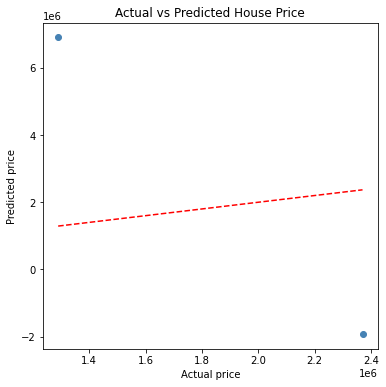

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,6))
plt.scatter(y_test,y_pred,color ='steelblue')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted House Price")
plt.show()